# Importación de librerías

In [249]:
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.cluster import KMeans, OPTICS, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from sklearn.manifold import TSNE
import umap

# Importación de datos

In [250]:
planetas = pd.read_csv("https://raw.githubusercontent.com/MoonieMoons/InteligenciaArtificial/refs/heads/main/Proyecto/base_planetas.csv", comment='#')

# Exploración de datos

Primero, revisamos los valores faltantes de las columnas a utilizar:

In [251]:
planetas[['pl_rade','pl_bmasse','pl_orbper','pl_eqt','pl_orbsmax','pl_insol',"pl_orbeccen","pl_insol", "pl_dens"]].isna().sum()

,0
pl_rade,61
pl_bmasse,42
pl_orbper,344
pl_eqt,1609
pl_orbsmax,439
pl_insol,1884
pl_orbeccen,1063
pl_insol,1884
pl_dens,150


Revisamos la correlación de las columnas en general

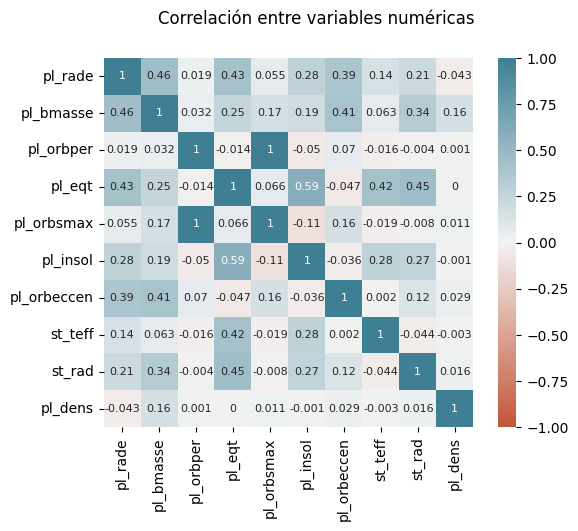

In [252]:
numeric_cols = [
    'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_orbsmax', 'pl_insol', 'pl_orbeccen',
    'st_teff', 'st_rad', 'pl_dens'
]

planetas = planetas.loc[:, ["pl_name"] + numeric_cols]

sns.heatmap(
    round(planetas[numeric_cols].corr(), 3),
    vmin = -1, vmax = 1, center = 0,
    cmap = sns.diverging_palette(20, 220, n = 256),
    annot = True,
    annot_kws={'fontsize': 8},
    square = True
)

plt.suptitle("Correlación entre variables numéricas")
plt.show()

In [253]:
def plot_column(col, title):
  fig, axs = plt.subplots(figsize=(10, 5), ncols=2)
  sns.histplot(planetas[col], ax=axs[0])
  sns.boxplot(planetas[col], ax=axs[1], orient='h')
  plt.suptitle(title)
  plt.savefig(f"{title}.png")
  plt.show()

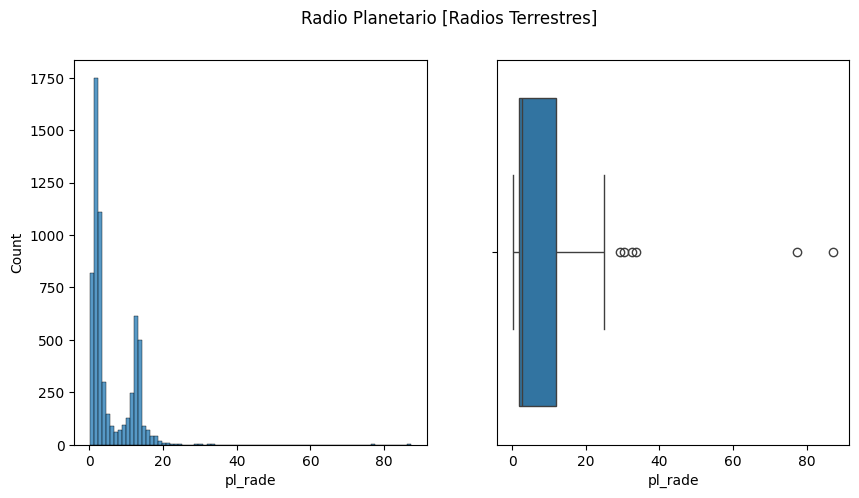

In [254]:
col = "pl_rade"
title = "Radio Planetario [Radios Terrestres]"

plot_column(col, title)
planetas = planetas[planetas["pl_rade"] < 40]

Observando que los outliers son aquellos que se encuentran por encima de 40, decidimos removerlos

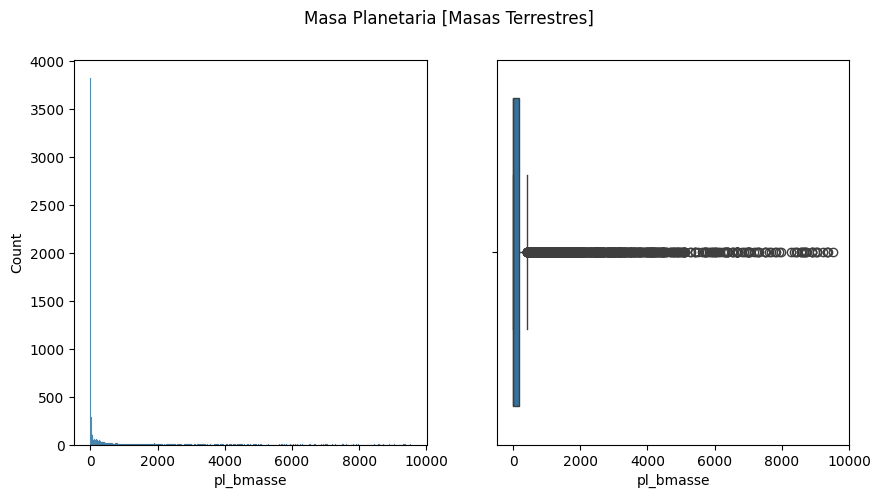

In [255]:
col = "pl_bmasse"
title = "Masa Planetaria [Masas Terrestres]"

plot_column(col, title)

A pesar de la rara distribución, no quitamos nada porque termina quitando demasiados datos

In [256]:
q = planetas['pl_orbper'].quantile(0.99)
planetas = planetas[planetas['pl_orbper'] < q]
planetas['pl_orbper'].describe()

,pl_orbper
count,5817.000000
mean,231.726587
std,968.541991
min,0.112007
25%,4.263742
50%,10.456233
75%,35.473580
max,13921.423020


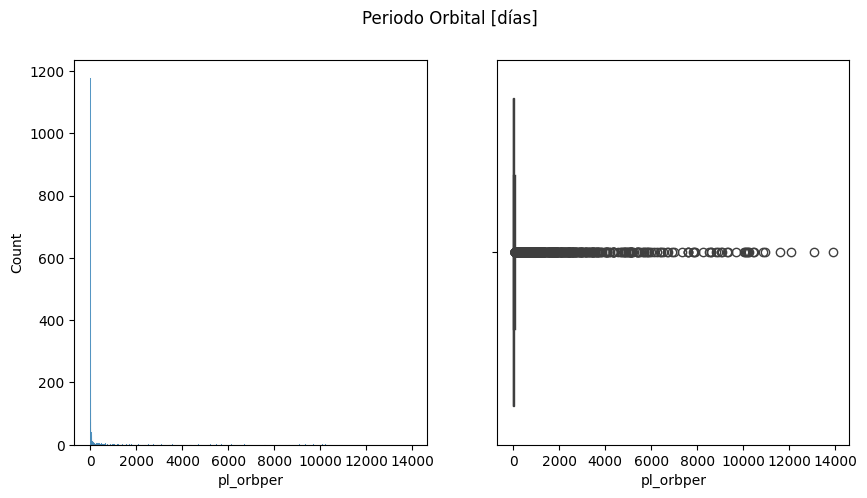

In [257]:
col = "pl_orbper"
title = "Periodo Orbital [días]"

plot_column(col, title)

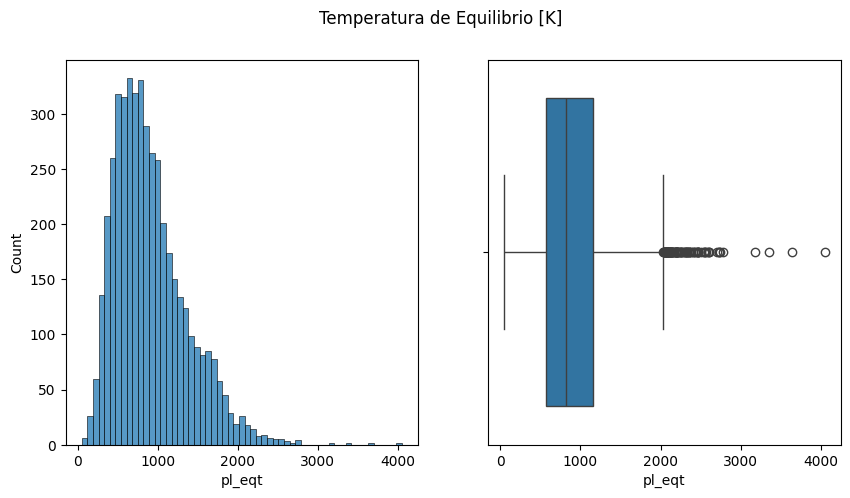

In [258]:
col = "pl_eqt"
title = "Temperatura de Equilibrio [K]"

plot_column(col, title)

In [259]:
print(f"Planetas que quedan: {len(planetas)}")

Planetas que quedan: 5817


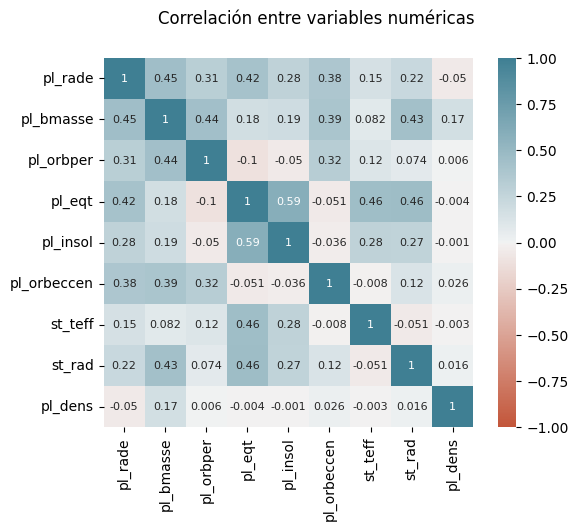

In [260]:
numeric_cols = [
    'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_insol', 'pl_orbeccen',
    'st_teff', 'st_rad', 'pl_dens'
]

sns.heatmap(
    round(planetas[numeric_cols].corr(), 3),
    vmin = -1, vmax = 1, center = 0,
    cmap = sns.diverging_palette(20, 220, n = 256),
    annot = True,
    annot_kws={'fontsize': 8},
    square = True
)

plt.suptitle("Correlación entre variables numéricas")
plt.savefig("Correlación de variables.png")
plt.show()

# Preprocesamiento de datos

Se hizo una clasificación de exoplanetas por tipo según la masa:

In [261]:
def clasificar(row):
    r = row['pl_rade']
    m = row['pl_bmasse']

    if pd.isna(r) and pd.isna(m):
        return 'Sin clasificar'

    if not pd.isna(r):
        if r < 1.25:   return 'Terrestre'
        elif r < 2.0:  return 'Super-Tierra'
        elif r < 4.0:  return 'Sub-Neptuno'
        elif r < 10.0: return 'Neptuniano'
        else:          return 'Gigante gaseoso'

#checar masas, especialmente las obtenidas por velocidad radial
    if not pd.isna(m):
        if m < 2:    return 'Terrestre'
        elif m < 10: return 'Super-Tierra'
        elif m < 20: return 'Sub-Neptuno'
        elif m < 50: return 'Neptuniano'
        else:        return 'Gigante gaseoso'

planetas['tipo_planeta'] = planetas.apply(clasificar, axis=1)
print(planetas['tipo_planeta'].value_counts())

tipo_planeta
Sub-Neptuno        2036
Gigante gaseoso    1479
Super-Tierra       1179
Terrestre           571
Neptuniano          552
Name: count, dtype: int64


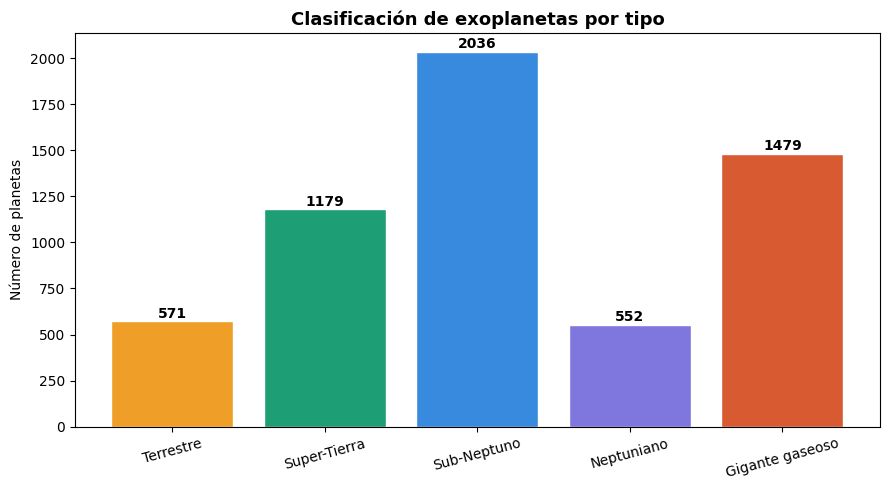

In [262]:
conteo = planetas['tipo_planeta'].value_counts()

colores = {
    'Terrestre':       '#EF9F27',
    'Super-Tierra':    '#1D9E75',
    'Sub-Neptuno':     '#378ADD',
    'Neptuniano':      '#7F77DD',
    'Gigante gaseoso': '#D85A30',
    'Sin clasificar':  '#888780'
}

orden = ['Terrestre', 'Super-Tierra', 'Sub-Neptuno', 'Neptuniano', 'Gigante gaseoso']
valores = [conteo[t] for t in orden]
colores_ord = [colores[t] for t in orden]

plt.figure(figsize=(9, 5))
bars = plt.bar(orden, valores, color=colores_ord, edgecolor='white')

for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=10, fontweight='bold')

plt.title('Clasificación de exoplanetas por tipo', fontsize=13, fontweight='bold')
plt.ylabel('Número de planetas')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("Clasificación de exoplanetas.png")
plt.show()

In [263]:
print(planetas[planetas['tipo_planeta'] == 'Sin clasificar']['pl_name'])
# 7 planetas sin clasificar

Series([], Name: pl_name, dtype: object)


Revisamos las temperaturas de equilibrio faltantes para cada tipo de planeta

In [264]:
# Equilibrium Temperature [K]
print(planetas.groupby('tipo_planeta')['pl_eqt'].apply(lambda x: x.isna().sum()))

tipo_planeta
Gigante gaseoso    710
Neptuniano         129
Sub-Neptuno        233
Super-Tierra        97
Terrestre           54
Name: pl_eqt, dtype: int64


Ahora, vamos a calcular la temperatura de la estrella

In [265]:
# Stellar Effective Temperature [K]
print(f"Faltantes st_teff:\t{planetas['st_teff'].isna().sum()}")
# Stellar Radius [Solar Radius]
print(f"Faltantes st_rad:\t{planetas['st_rad'].isna().sum()}")
# Orbit Semi-Major Axis [au]
print(f"Faltantes pl_orbsmax:\t{planetas['pl_orbsmax'].isna().sum()}")

Faltantes st_teff:	30
Faltantes st_rad:	43
Faltantes pl_orbsmax:	413


In [266]:
mask = planetas['st_teff'].notna() & planetas['st_rad'].notna() & planetas['pl_orbsmax'].notna()
print(f"Planetas con las 3 variables completas: {mask.sum()}")
print(f"Planetas sin al menos una: {(~mask).sum()}")

Planetas con las 3 variables completas: 5358
Planetas sin al menos una: 459


In [267]:
def calcular_temp_eq(row):
    # Si ya tiene temperatura medida, la dejamos
    if not pd.isna(row['pl_eqt']):
        return row['pl_eqt']

    # Si tiene las 3 variables, calculamos con la fórmula
    if not pd.isna(row['st_teff']) and not pd.isna(row['st_rad']) and not pd.isna(row['pl_orbsmax']):
        A = 0.3
        T_star = row['st_teff']
        R_star = row['st_rad'] * 6.957e8  # radios solares a metros
        r = row['pl_orbsmax'] * 1.496e11  # AU a metros
        T_eq = T_star * ((R_star / (2 * r)) ** 0.5) * ((1 - A) ** 0.25)
        return T_eq

    return np.nan

planetas['pl_eqt'] = planetas.apply(calcular_temp_eq, axis=1)
print(f"Después de la fórmula, faltantes: {planetas['pl_eqt'].isna().sum()}")

Después de la fórmula, faltantes: 238


De los planetas que aún tiene un valor faltante, revisamos cuáles tienen flujo en unidades solares:

In [268]:
# T_eq = 278.5 * (F)^0.25   donde F es el flujo en unidades solares
# F = Insolation Flux [Earth Flux]
sin_temp = planetas['pl_eqt'].isna()
print(f"Planetas CON flujo: {(sin_temp & planetas['pl_insol'].notna()).sum()}")
print(f"Planetas SIN flujo: {(sin_temp & planetas['pl_insol'].isna()).sum()}")

Planetas CON flujo: 0
Planetas SIN flujo: 238


Imputamos los datos faltantes por medio de KNN

In [269]:
num_df = planetas.loc[:, numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

imputer = KNNImputer(n_neighbors=5)
X_scaled_imputed = imputer.fit_transform(X_scaled)

X_imputed = scaler.inverse_transform(X_scaled_imputed)

planetas.loc[:, numeric_cols] = X_imputed

In [270]:
planetas = planetas.dropna(subset=['pl_eqt'])
print(f"Planetas restantes: {len(planetas)}")

Planetas restantes: 5817


# Construcción de modelos

Normalización de los datos para la aplicación de los algoritmos de clustering

In [271]:
num_df = planetas.loc[:, numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

In [272]:
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# X_pos = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2)
X_pos = reducer.fit_transform(X_scaled)

planetas['x'] = X_pos[:, 0]
planetas['y'] = X_pos[:, 1]

In [273]:
cols_clustering = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_orbsmax']
X_clustering_data = planetas[cols_clustering]
X = X_clustering_data.dropna()
idx = X.index

## K-Means

In [274]:
for k in range(2, 31):
    clusterer = KMeans(n_clusters=k)
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.571	CHS: 1249.415
k=3 -> Clústeres: 	3,	Silhouette:0.454	CHS: 1150.655
k=4 -> Clústeres: 	4,	Silhouette:0.464	CHS: 1104.334
k=5 -> Clústeres: 	5,	Silhouette:0.432	CHS: 992.052
k=6 -> Clústeres: 	6,	Silhouette:0.281	CHS: 953.746
k=7 -> Clústeres: 	7,	Silhouette:0.256	CHS: 1059.190
k=8 -> Clústeres: 	8,	Silhouette:0.269	CHS: 1064.970
k=9 -> Clústeres: 	9,	Silhouette:0.433	CHS: 1316.387
k=10 -> Clústeres: 	10,	Silhouette:0.460	CHS: 1332.632
k=11 -> Clústeres: 	11,	Silhouette:0.271	CHS: 1326.607
k=12 -> Clústeres: 	12,	Silhouette:0.464	CHS: 1246.810
k=13 -> Clústeres: 	13,	Silhouette:0.295	CHS: 1355.572
k=14 -> Clústeres: 	14,	Silhouette:0.293	CHS: 1448.393
k=15 -> Clústeres: 	15,	Silhouette:0.299	CHS: 1429.040
k=16 -> Clústeres: 	16,	Silhouette:0.288	CHS: 1369.135
k=17 -> Clústeres: 	17,	Silhouette:0.295	CHS: 1408.059
k=18 -> Clústeres: 	18,	Silhouette:0.279	CHS: 1286.871
k=19 -> Clústeres: 	19,	Silhouette:0.304	CHS: 1278.960
k=20 -> Clústeres: 	20,	Silh

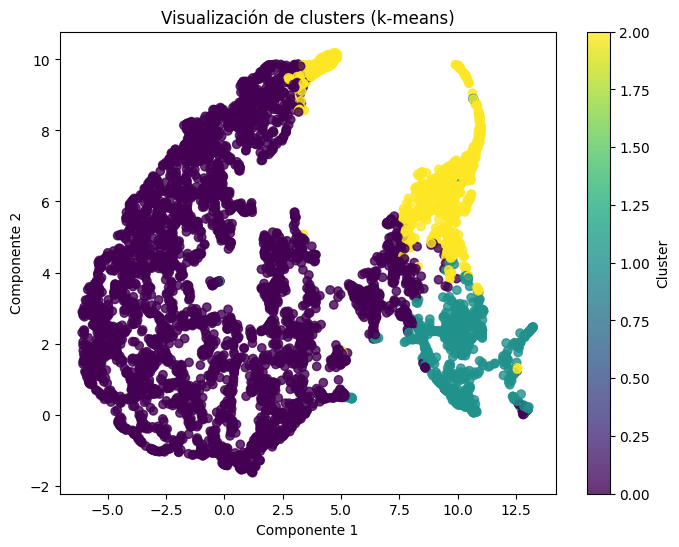

In [275]:
clusterer = KMeans(n_clusters=3)
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (k-means)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("k-means.png")
plt.show()

In [276]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.4525179127953917
Calinski-Harabasz: 1150.6714321581153


Counter({np.int32(1): 687, np.int32(2): 829, np.int32(0): 4301})

## OPTICS

In [277]:
for k in range(5, 12):
    clusterer = OPTICS(min_samples=k, xi=0.1)
    labels = clusterer.fit_predict(X_scaled)

    # Excluir puntos etiquetados como ruido (-1)
    mask = labels != -1
    if np.sum(mask) == 0:
        print(f"k={k} -> Solo ruido, no se puede calcular silhouette")
        continue

    labels_filtered = labels[mask]
    X_filtered = X_scaled[mask]

    # Número de clústeres reales (excluyendo -1)
    n_clusters = len(set(labels_filtered))
    if n_clusters < 2:
        print(f"k={k} -> Un solo clúster ({n_clusters}), silhouette no definida")
        continue

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{n_clusters},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=5 -> Clústeres: 	59,	Silhouette:-0.647	CHS: 9.619
k=6 -> Clústeres: 	32,	Silhouette:-0.634	CHS: 13.703
k=7 -> Clústeres: 	18,	Silhouette:-0.611	CHS: 25.514
k=8 -> Clústeres: 	9,	Silhouette:-0.453	CHS: 13.385
k=9 -> Clústeres: 	2,	Silhouette:-0.384	CHS: 4.483
k=10 -> Clústeres: 	3,	Silhouette:-0.443	CHS: 13.772
k=11 -> Un solo clúster (1), silhouette no definida


In [278]:
optics = OPTICS(min_samples=9, xi=0.1)
labels = optics.fit_predict(X_scaled)

# Número de clústeres detectados (sin ruido)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Clústeres: {n_clusters}, Ruido: {sum(labels==-1)}")
print(f"Silueta: {silhouette}")

Clústeres: 2, Ruido: 5788
Silueta: -0.44348376387992583


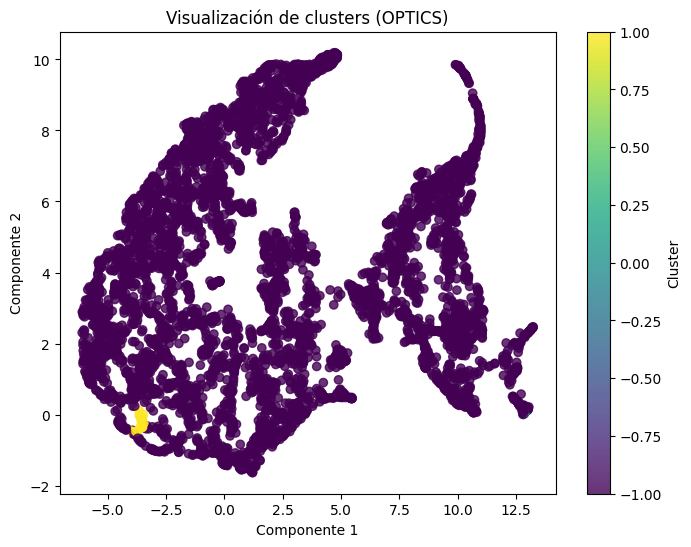

In [279]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (OPTICS)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("optics.png")
plt.show()

In [280]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: -0.3837764556578946
Calinski-Harabasz: 4.482609880969107


Counter({np.int64(-1): 5788, np.int64(1): 18, np.int64(0): 11})

## HDBSCAN

In [281]:
for k in range(2, 100, 2):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=k)
    labels = clusterer.fit_predict(X_scaled)

    # Excluir puntos etiquetados como ruido (-1)
    mask = labels != -1
    if np.sum(mask) == 0:
        print(f"k={k} -> Solo ruido, no se puede calcular silhouette")
        continue

    labels_filtered = labels[mask]
    X_filtered = X_scaled[mask]

    # Número de clústeres reales (excluyendo -1)
    n_clusters = len(set(labels_filtered))
    if n_clusters < 2:
        print(f"k={k} -> Un solo clúster ({n_clusters}), silhouette no definida")
        continue

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{n_clusters},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	613,	Silhouette:-0.306	CHS: 5.289
k=4 -> Clústeres: 	2,	Silhouette:0.833	CHS: 327.699
k=6 -> Clústeres: 	2,	Silhouette:0.833	CHS: 327.699
k=8 -> Clústeres: 	13,	Silhouette:-0.180	CHS: 49.199
k=10 -> Clústeres: 	9,	Silhouette:0.041	CHS: 91.656
k=12 -> Clústeres: 	6,	Silhouette:0.149	CHS: 174.241
k=14 -> Clústeres: 	4,	Silhouette:0.202	CHS: 256.142
k=16 -> Clústeres: 	4,	Silhouette:0.197	CHS: 251.189
k=18 -> Clústeres: 	3,	Silhouette:0.208	CHS: 332.504
k=20 -> Clústeres: 	3,	Silhouette:0.208	CHS: 330.863
k=22 -> Clústeres: 	3,	Silhouette:0.215	CHS: 338.314
k=24 -> Clústeres: 	3,	Silhouette:0.215	CHS: 336.101
k=26 -> Clústeres: 	3,	Silhouette:0.212	CHS: 333.685
k=28 -> Clústeres: 	3,	Silhouette:0.205	CHS: 326.006
k=30 -> Clústeres: 	3,	Silhouette:0.208	CHS: 329.749
k=32 -> Clústeres: 	2,	Silhouette:0.253	CHS: 484.606
k=34 -> Clústeres: 	2,	Silhouette:0.252	CHS: 487.024
k=36 -> Clústeres: 	2,	Silhouette:0.256	CHS: 487.545
k=38 -> Clústeres: 	2,	Silhouette:0.253	CHS: 485.

In [282]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=46)
labels = clusterer.fit_predict(X_scaled)

# Resultados
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
print(f"Clústeres encontrados: {n_clusters}")
print(f"Puntos ruido: {n_noise}")


Clústeres encontrados: 2
Puntos ruido: 1920


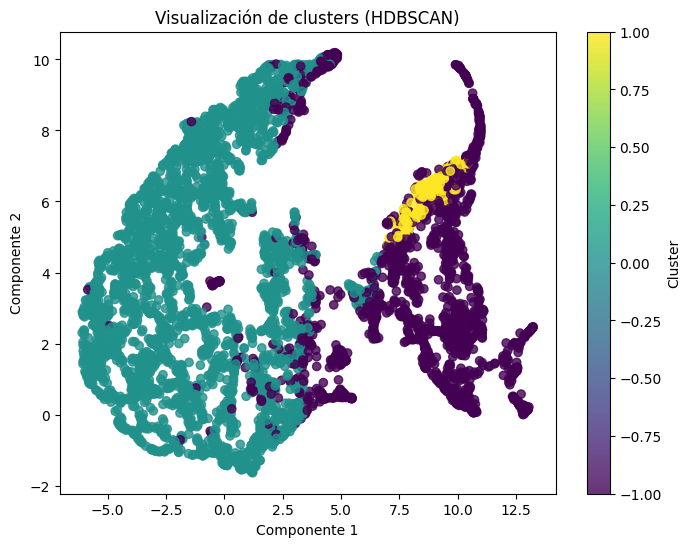

In [283]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (HDBSCAN)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("hdbscan.png")
plt.show()

In [284]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.2767258663479686
Calinski-Harabasz: 527.1910144230981


Counter({np.int64(-1): 1920, np.int64(1): 248, np.int64(0): 3649})

# Clasificación de planetas

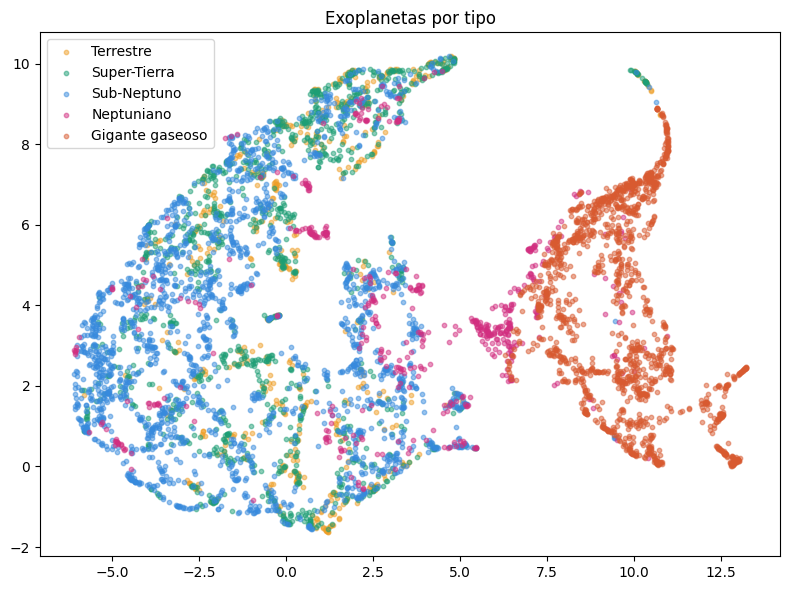

In [287]:
colores = ['#EF9F27', '#1D9E75', '#378ADD', '#D22E80', '#D85A30', '#888780']
nombres = ['Terrestre', 'Super-Tierra', 'Sub-Neptuno', 'Neptuniano', 'Gigante gaseoso']

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(5):
    sub = planetas[planetas["tipo_planeta"] == nombres[i]]
    ax.scatter(sub['x'], sub['y'],
               c=colores[i], s=10, alpha=0.5,
               label=nombres[i])

ax.set_title('Exoplanetas por tipo')
ax.legend()
plt.tight_layout()
plt.savefig("Exoplanetas Tipo.png")
plt.show()